# 1. IMPORT PACKAGE AND DATASET

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_original.data.features
y = breast_cancer_wisconsin_original.data.targets

# metadata
print(breast_cancer_wisconsin_original.metadata)

# variable information
print(breast_cancer_wisconsin_original.variables)

{'uci_id': 15, 'name': 'Breast Cancer Wisconsin (Original)', 'repository_url': 'https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original', 'data_url': 'https://archive.ics.uci.edu/static/public/15/data.csv', 'abstract': 'Original Wisconsin Breast Cancer Database', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 699, 'num_features': 9, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['Class'], 'index_col': ['Sample_code_number'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1990, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5HP4Z', 'creators': ['WIlliam Wolberg'], 'intro_paper': None, 'additional_info': {'summary': "Samples arrive periodically as Dr. Wolberg reports his clinical cases. The database therefore reflects this chronological grouping of the data. This grouping information appears immediately below, having been removed fro

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
# Combine features and target
df = pd.concat([X, y], axis=1)

# Check
df.head()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2


In [ ]:
df.mean()

,0
Clump_thickness,4.417740
Uniformity_of_cell_size,3.134478
Uniformity_of_cell_shape,3.207439
Marginal_adhesion,2.806867
Single_epithelial_cell_size,3.216023
Bare_nuclei,3.544656
Bland_chromatin,3.437768
Normal_nucleoli,2.866953
Mitoses,1.589413
Class,2.689557


In [ ]:
df.median()

,0
Clump_thickness,4.0
Uniformity_of_cell_size,1.0
Uniformity_of_cell_shape,1.0
Marginal_adhesion,1.0
Single_epithelial_cell_size,2.0
Bare_nuclei,1.0
Bland_chromatin,3.0
Normal_nucleoli,1.0
Mitoses,1.0
Class,2.0


In [ ]:
df.mode()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,1,1,1,1,2,1.0,2,1,1,2


In [ ]:
df.corr()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
Clump_thickness,1.000000,0.644913,0.654589,0.486356,0.521816,0.593091,0.558428,0.535835,0.350034,0.716001
Uniformity_of_cell_size,0.644913,1.000000,0.906882,0.705582,0.751799,0.691709,0.755721,0.722865,0.458693,0.817904
Uniformity_of_cell_shape,0.654589,0.906882,1.000000,0.683079,0.719668,0.713878,0.735948,0.719446,0.438911,0.818934
Marginal_adhesion,0.486356,0.705582,0.683079,1.000000,0.599599,0.670648,0.666715,0.603352,0.417633,0.696800
Single_epithelial_cell_size,0.521816,0.751799,0.719668,0.599599,1.000000,0.585716,0.616102,0.628881,0.479101,0.682785
Bare_nuclei,0.593091,0.691709,0.713878,0.670648,0.585716,1.000000,0.680615,0.584280,0.339210,0.822696
Bland_chromatin,0.558428,0.755721,0.735948,0.666715,0.616102,0.680615,1.000000,0.665878,0.344169,0.756616
Normal_nucleoli,0.535835,0.722865,0.719446,0.603352,0.628881,0.584280,0.665878,1.000000,0.428336,0.712244
Mitoses,0.350034,0.458693,0.438911,0.417633,0.479101,0.339210,0.344169,0.428336,1.000000,0.423170
Class,0.716001,0.817904,0.818934,0.696800,0.682785,0.822696,0.756616,0.712244,0.423170,1.000000


In [ ]:
df.cov()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
Clump_thickness,7.928395,5.541164,5.477690,3.910308,3.253469,6.096061,3.834057,4.607235,1.690389,1.917836
Uniformity_of_cell_size,5.541164,9.311403,8.224213,6.147786,5.079791,7.725660,5.622994,6.735683,2.400566,2.374186
Uniformity_of_cell_shape,5.477690,8.224213,8.832265,5.796568,4.735926,7.774099,5.333128,6.529071,2.237156,2.315207
Marginal_adhesion,3.910308,6.147786,5.796568,8.153191,3.791065,7.000264,4.641975,5.260800,2.045230,1.892679
Single_epithelial_cell_size,3.253469,5.079791,4.735926,3.791065,4.903124,4.744656,3.326500,4.252278,1.819482,1.438219
Bare_nuclei,6.096061,7.725660,7.774099,7.000264,4.744656,13.277695,6.075403,6.499229,2.141645,2.861663
Bland_chromatin,3.834057,5.622994,5.333128,4.641975,3.326500,6.075403,5.945620,4.958041,1.439312,1.755008
Normal_nucleoli,4.607235,6.735683,6.529071,5.260800,4.252278,6.499229,4.958041,9.324680,2.243289,2.068952
Mitoses,1.690389,2.400566,2.237156,2.045230,1.819482,2.141645,1.439312,2.243289,2.941492,0.690405
Class,1.917836,2.374186,2.315207,1.892679,1.438219,2.861663,1.755008,2.068952,0.690405,0.904919


In [ ]:
df.quantile([0.25, 0.5, 0.75])

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0.25,2.0,1.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0,2.0
0.50,4.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0,2.0
0.75,6.0,5.0,5.0,4.0,4.0,6.0,5.0,4.0,1.0,4.0


In [ ]:
df.max()

,0
Clump_thickness,10.0
Uniformity_of_cell_size,10.0
Uniformity_of_cell_shape,10.0
Marginal_adhesion,10.0
Single_epithelial_cell_size,10.0
Bare_nuclei,10.0
Bland_chromatin,10.0
Normal_nucleoli,10.0
Mitoses,10.0
Class,4.0


In [ ]:
df.min()

,0
Clump_thickness,1.0
Uniformity_of_cell_size,1.0
Uniformity_of_cell_shape,1.0
Marginal_adhesion,1.0
Single_epithelial_cell_size,1.0
Bare_nuclei,1.0
Bland_chromatin,1.0
Normal_nucleoli,1.0
Mitoses,1.0
Class,2.0


In [ ]:
df.sum()

,0
Clump_thickness,3088.0
Uniformity_of_cell_size,2191.0
Uniformity_of_cell_shape,2242.0
Marginal_adhesion,1962.0
Single_epithelial_cell_size,2248.0
Bare_nuclei,2421.0
Bland_chromatin,2403.0
Normal_nucleoli,2004.0
Mitoses,1111.0
Class,1880.0


In [ ]:
df.std()

,0
Clump_thickness,2.815741
Uniformity_of_cell_size,3.051459
Uniformity_of_cell_shape,2.971913
Marginal_adhesion,2.855379
Single_epithelial_cell_size,2.214300
Bare_nuclei,3.643857
Bland_chromatin,2.438364
Normal_nucleoli,3.053634
Mitoses,1.715078
Class,0.951273


In [ ]:
df.quantile(0.9)

,0.9
Clump_thickness,9.0
Uniformity_of_cell_size,9.0
Uniformity_of_cell_shape,8.0
Marginal_adhesion,8.0
Single_epithelial_cell_size,6.0
Bare_nuclei,10.0
Bland_chromatin,7.0
Normal_nucleoli,9.0
Mitoses,3.0
Class,4.0


In [ ]:
df.tail()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
694,3,1,1,1,3,2.0,1,1,1,2
695,2,1,1,1,2,1.0,1,1,1,2
696,5,10,10,3,7,3.0,8,10,2,4
697,4,8,6,4,3,4.0,10,6,1,4
698,4,8,8,5,4,5.0,10,4,1,4


In [ ]:
df.dtypes

,0
Clump_thickness,int64
Uniformity_of_cell_size,int64
Uniformity_of_cell_shape,int64
Marginal_adhesion,int64
Single_epithelial_cell_size,int64
Bare_nuclei,float64
Bland_chromatin,int64
Normal_nucleoli,int64
Mitoses,int64
Class,int64


In [ ]:
df.shape

(699, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump_thickness              699 non-null    int64  
 1   Uniformity_of_cell_size      699 non-null    int64  
 2   Uniformity_of_cell_shape     699 non-null    int64  
 3   Marginal_adhesion            699 non-null    int64  
 4   Single_epithelial_cell_size  699 non-null    int64  
 5   Bare_nuclei                  683 non-null    float64
 6   Bland_chromatin              699 non-null    int64  
 7   Normal_nucleoli              699 non-null    int64  
 8   Mitoses                      699 non-null    int64  
 9   Class                        699 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 54.7 KB


In [ ]:
df.describe()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
count,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413,2.689557
std,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078,0.951273
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [ ]:
df.describe(percentiles = [0.1, 0.25, 0.5, 0.75, 0.9])

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
count,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413,2.689557
std,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078,0.951273
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
10%,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
90%,9.000000,9.000000,8.000000,8.000000,6.000000,10.000000,7.000000,9.000000,3.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [ ]:
df.columns

Index(['Clump_thickness', 'Uniformity_of_cell_size',
       'Uniformity_of_cell_shape', 'Marginal_adhesion',
       'Single_epithelial_cell_size', 'Bare_nuclei', 'Bland_chromatin',
       'Normal_nucleoli', 'Mitoses', 'Class'],
      dtype='object')

In [ ]:
df.nunique()

,0
Clump_thickness,10
Uniformity_of_cell_size,10
Uniformity_of_cell_shape,10
Marginal_adhesion,10
Single_epithelial_cell_size,10
Bare_nuclei,10
Bland_chromatin,10
Normal_nucleoli,10
Mitoses,9
Class,2


# 2. BASIC PLOTTING

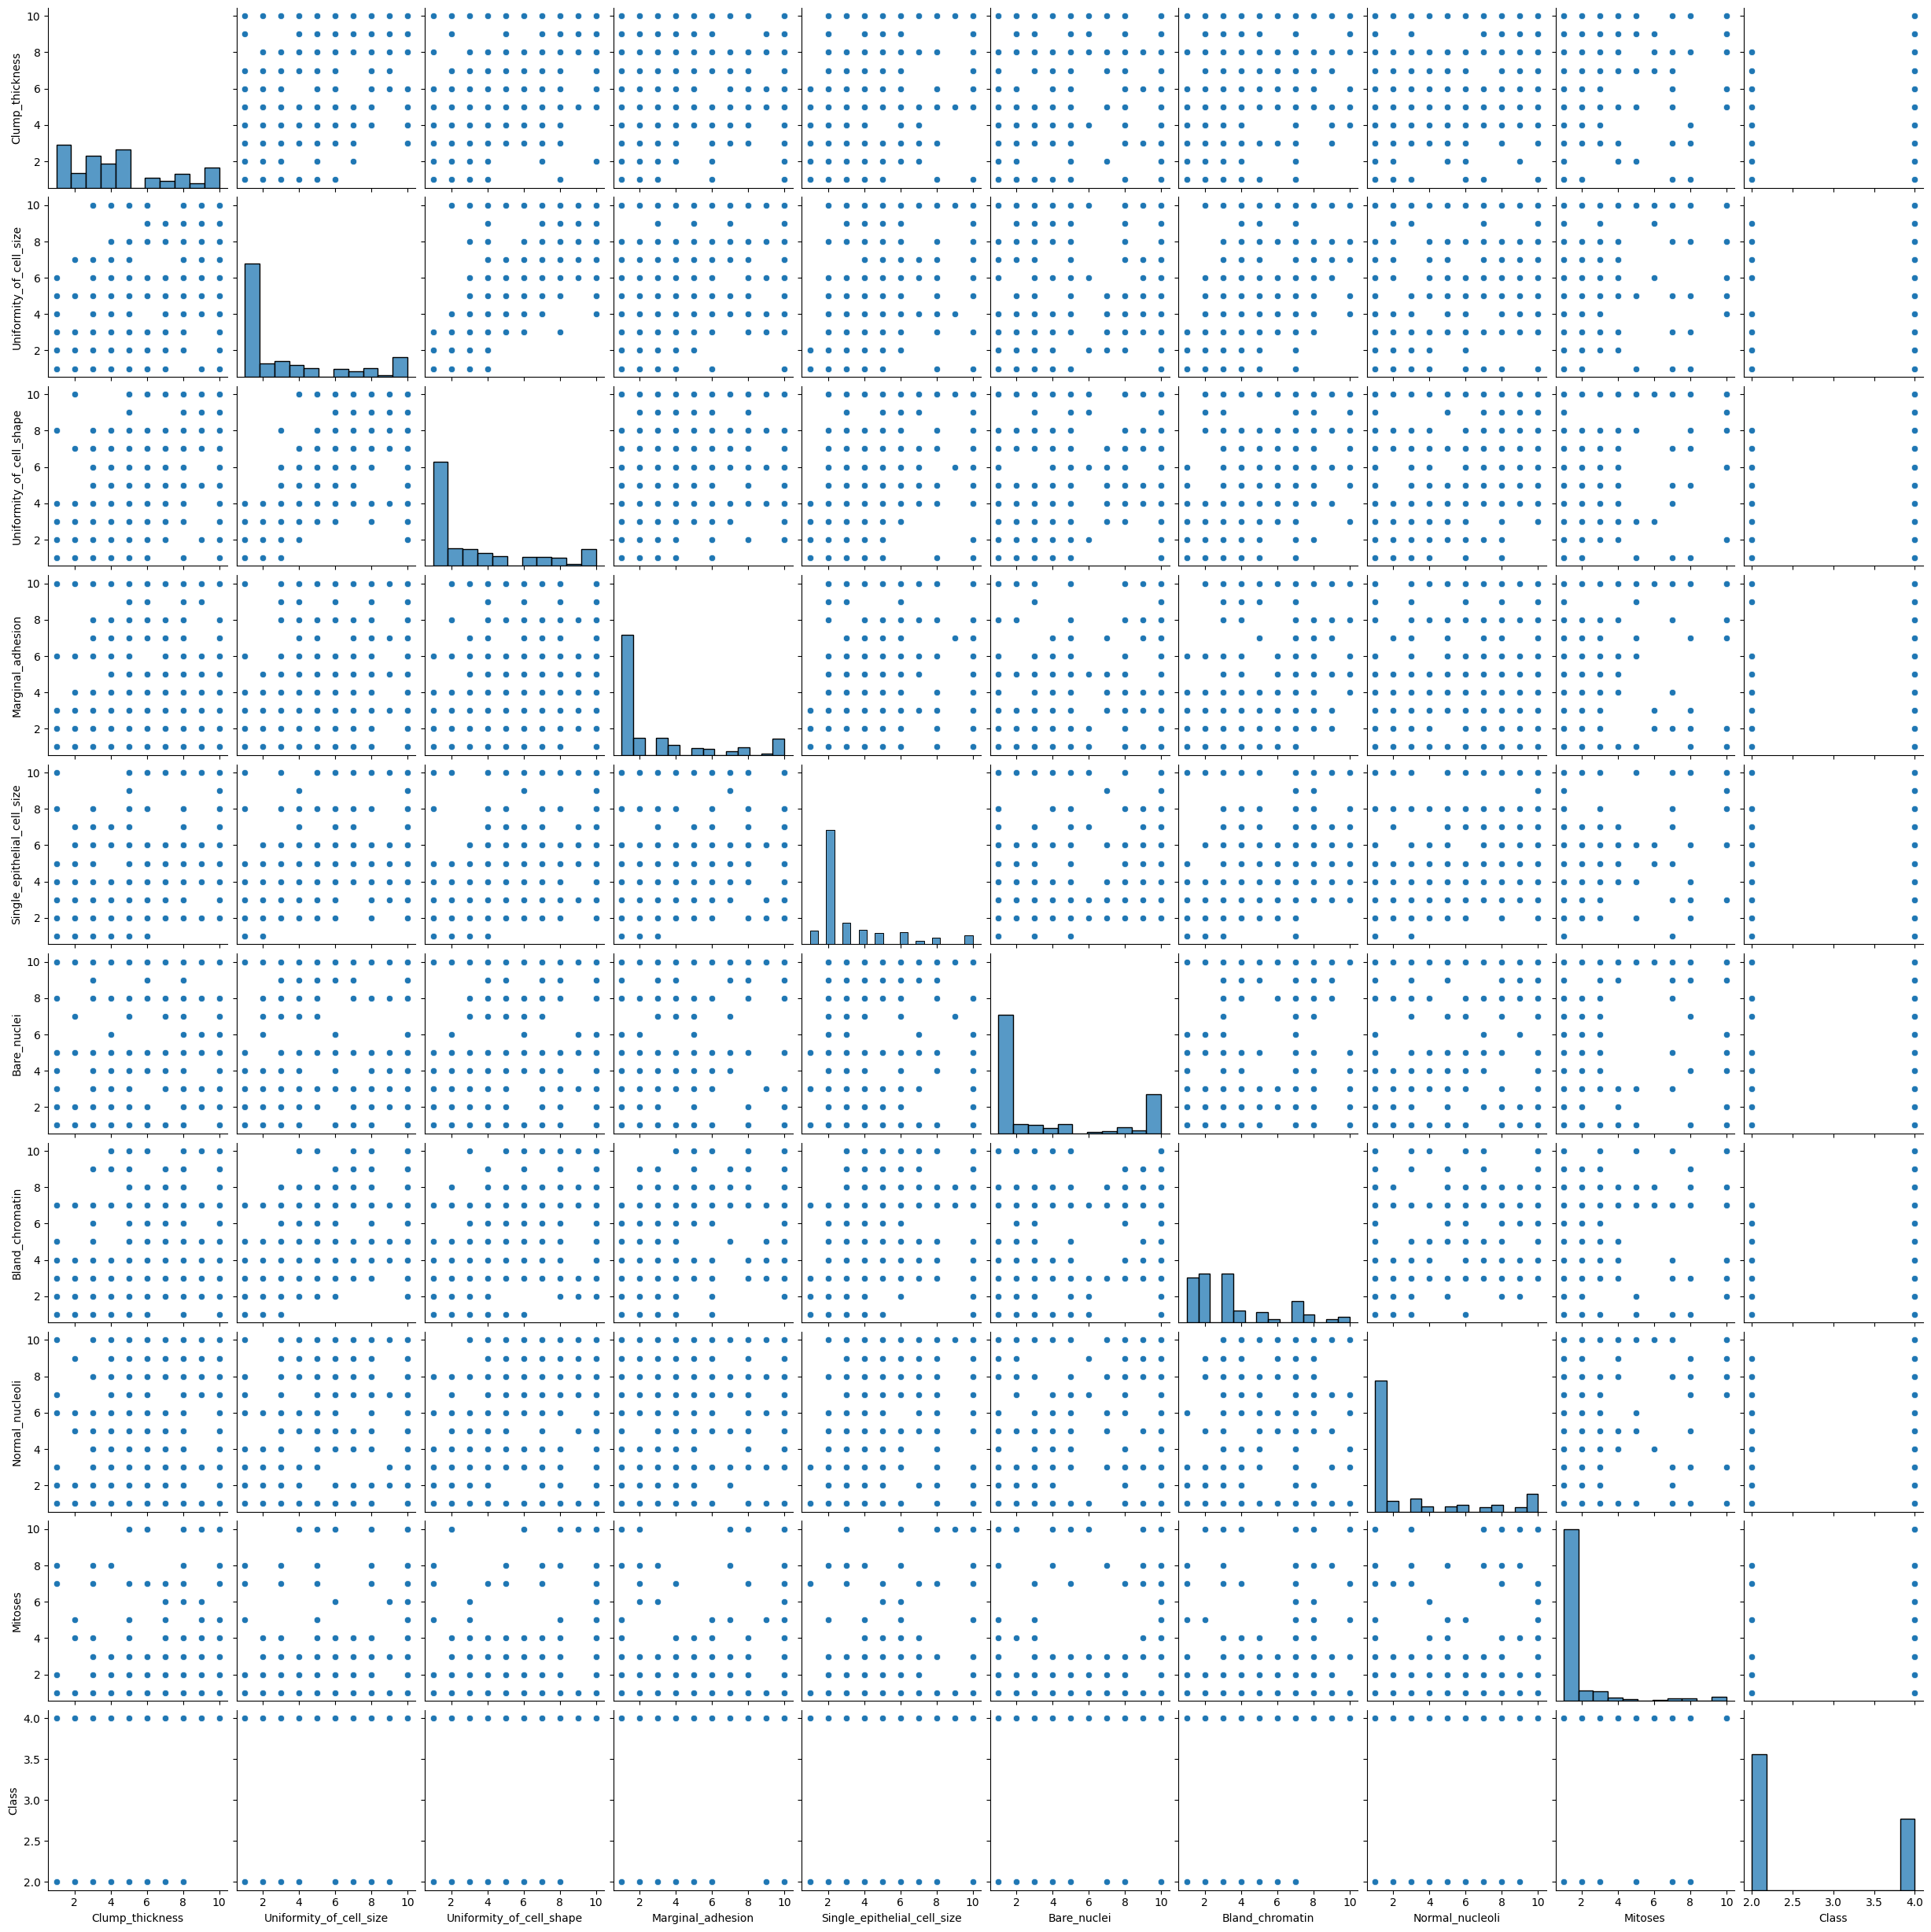

In [ ]:
sns.pairplot(df)

<Axes: >

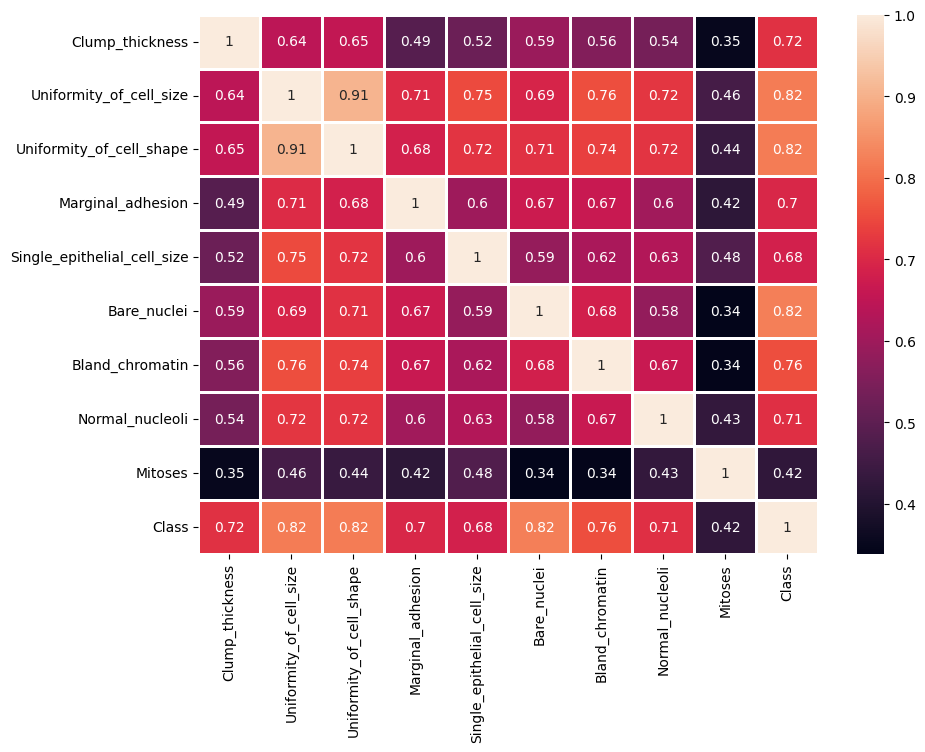

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(),annot=True,linewidths=2)

### Univariate analysis

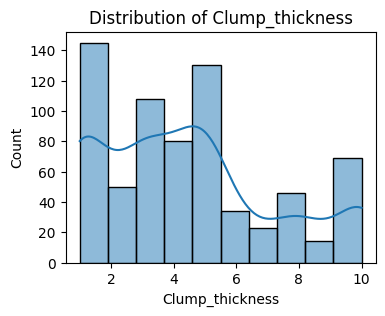

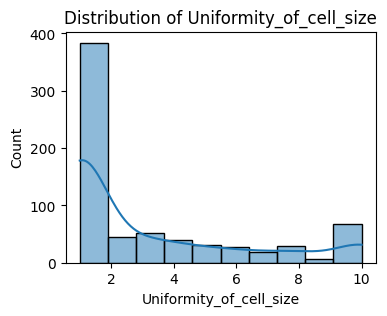

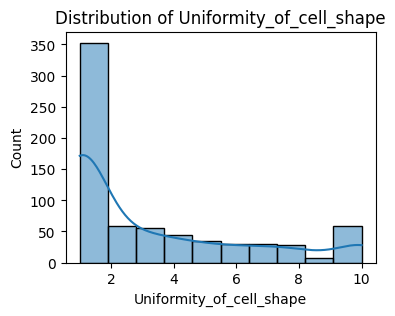

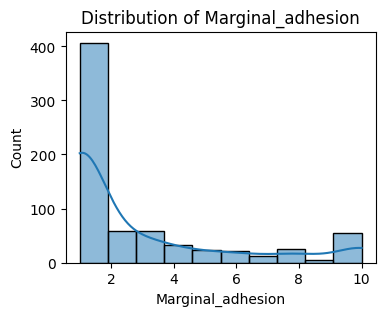

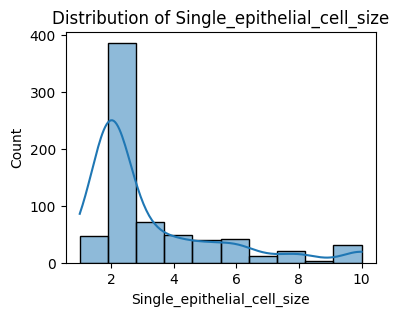

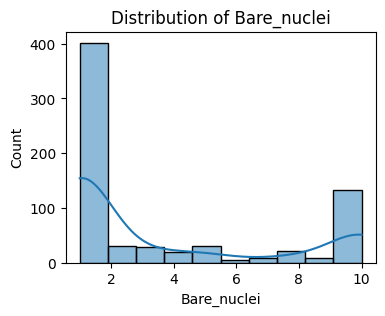

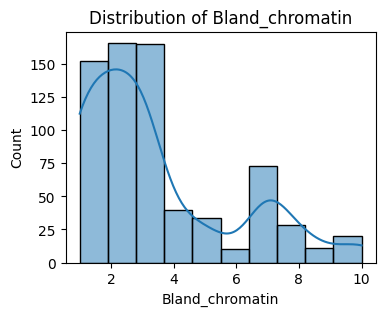

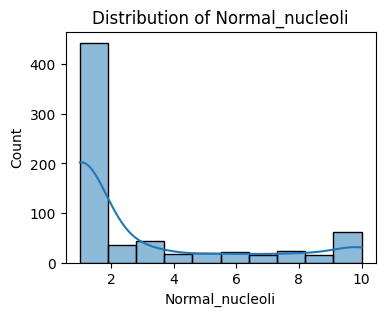

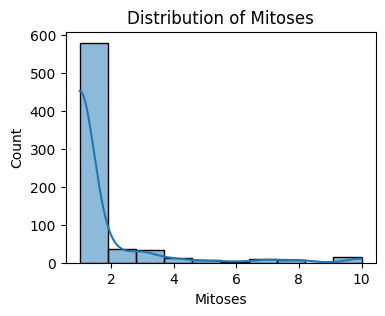

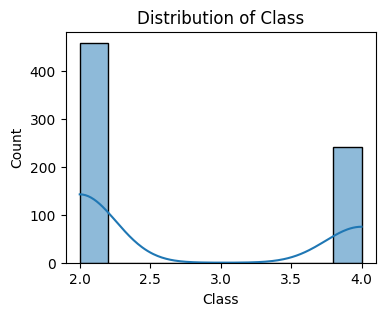

In [ ]:
for col in df.columns:
    plt.figure(figsize=(4,3))
    sns.histplot(df[col], bins=10, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
for col in df.columns:
    print(f"\n{col} value counts:")
    print(df[col].value_counts().sort_index())


Clump_thickness value counts:
Clump_thickness
1     145
2      50
3     108
4      80
5     130
6      34
7      23
8      46
9      14
10     69
Name: count, dtype: int64

Uniformity_of_cell_size value counts:
Uniformity_of_cell_size
1     384
2      45
3      52
4      40
5      30
6      27
7      19
8      29
9       6
10     67
Name: count, dtype: int64

Uniformity_of_cell_shape value counts:
Uniformity_of_cell_shape
1     353
2      59
3      56
4      44
5      34
6      30
7      30
8      28
9       7
10     58
Name: count, dtype: int64

Marginal_adhesion value counts:
Marginal_adhesion
1     407
2      58
3      58
4      33
5      23
6      22
7      13
8      25
9       5
10     55
Name: count, dtype: int64

Single_epithelial_cell_size value counts:
Single_epithelial_cell_size
1      47
2     386
3      72
4      48
5      39
6      41
7      12
8      21
9       2
10     31
Name: count, dtype: int64

Bare_nuclei value counts:
Bare_nuclei
1.0     402
2.0      30
3.0      2

# 3. DATA PREPROCESSING

### Handling missing values

In [ ]:
df.isnull().sum()

,0
Clump_thickness,0
Uniformity_of_cell_size,0
Uniformity_of_cell_shape,0
Marginal_adhesion,0
Single_epithelial_cell_size,0
Bare_nuclei,16
Bland_chromatin,0
Normal_nucleoli,0
Mitoses,0
Class,0


In [ ]:
(df.isnull().sum()/(len(df)))*100

,0
Clump_thickness,0.000000
Uniformity_of_cell_size,0.000000
Uniformity_of_cell_shape,0.000000
Marginal_adhesion,0.000000
Single_epithelial_cell_size,0.000000
Bare_nuclei,2.288984
Bland_chromatin,0.000000
Normal_nucleoli,0.000000
Mitoses,0.000000
Class,0.000000


In [ ]:
df.replace('?', np.nan, inplace=True)

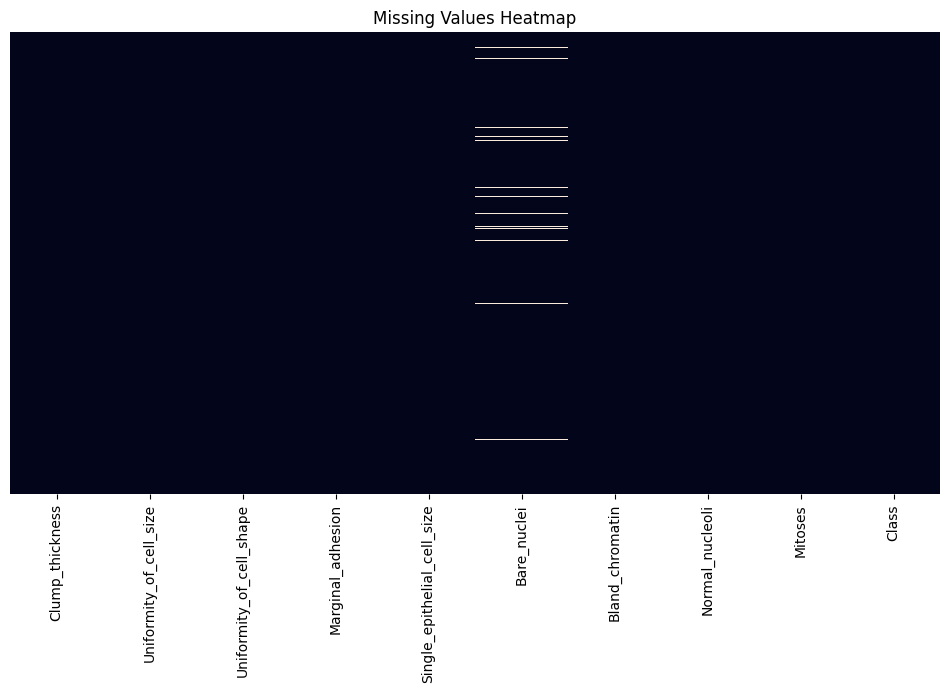

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
df.isnull().sum()

,0
Clump_thickness,0
Uniformity_of_cell_size,0
Uniformity_of_cell_shape,0
Marginal_adhesion,0
Single_epithelial_cell_size,0
Bare_nuclei,16
Bland_chromatin,0
Normal_nucleoli,0
Mitoses,0
Class,0


In [ ]:
df = df.dropna()

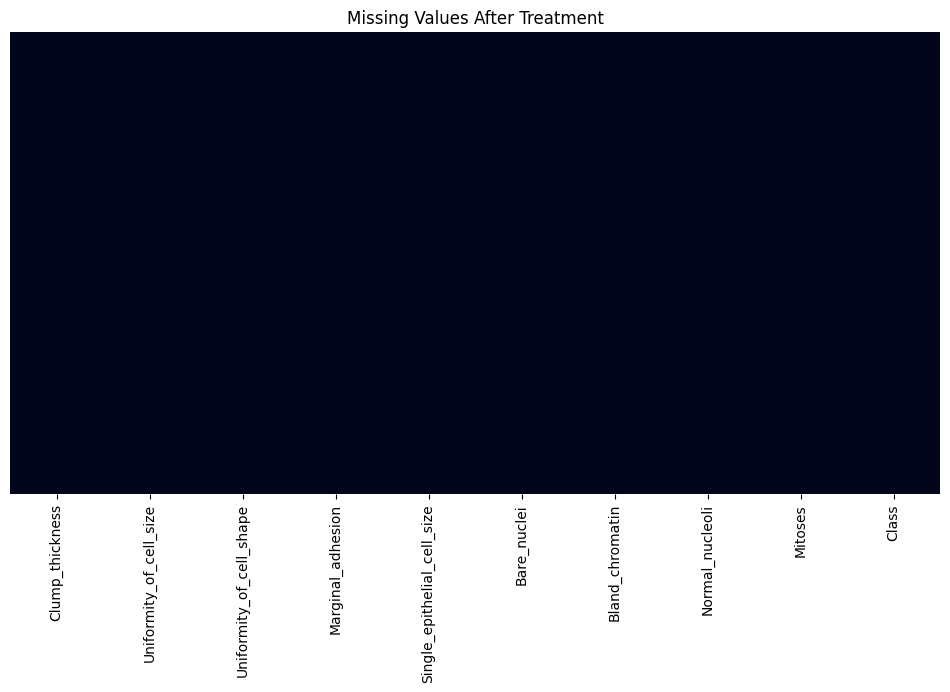

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values After Treatment")
plt.show()

### Outlier detection and removal

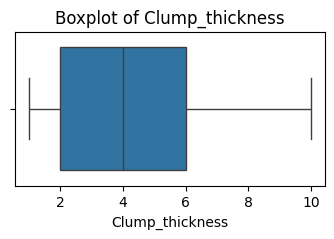

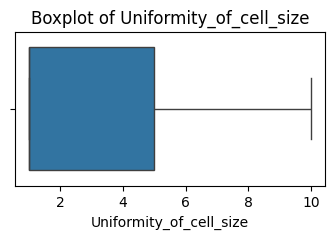

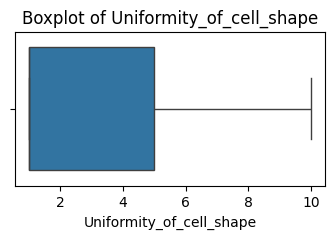

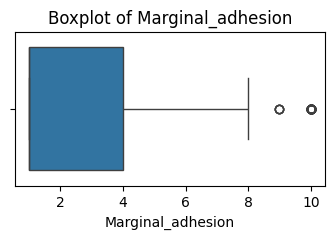

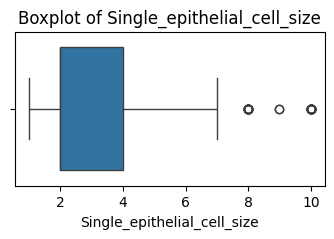

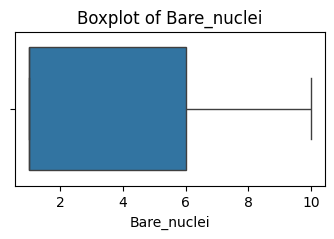

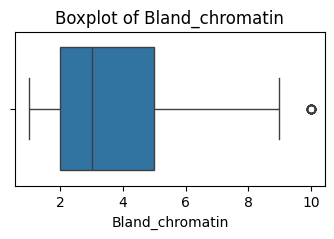

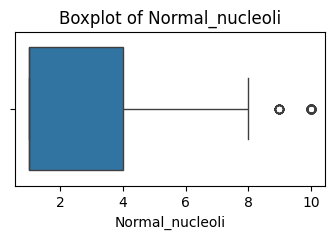

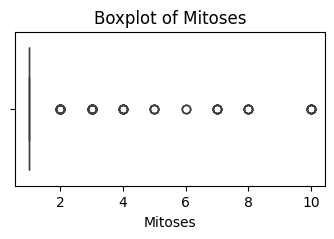

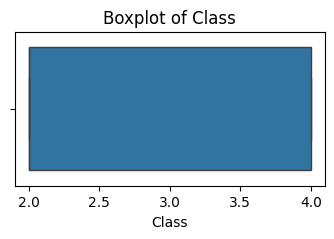

In [ ]:
for col in df.columns:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
num_cols = df.columns.drop('Class')

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {count} outliers")

Clump_thickness: 0 outliers
Uniformity_of_cell_size: 0 outliers
Uniformity_of_cell_shape: 0 outliers
Marginal_adhesion: 59 outliers
Single_epithelial_cell_size: 54 outliers
Bare_nuclei: 0 outliers
Bland_chromatin: 20 outliers
Normal_nucleoli: 75 outliers
Mitoses: 120 outliers


Mitoses feature is: Discrete ordinal (values like 1–10), Highly skewed, Dominated by a single value (mostly 1)

What happens statistically?

For Mitoses in this dataset:

Q1 = 1

Median = 1

Q3 = 1

IQR = Q3 − Q1 = 0

Hence we don't treat the outliers in the column Mitoses as they are not exactly outliers but trends in the data.

Same for the rest of the features, they are clinically meaningful so if we treat them we may miss out on trends in data

### Encoding column data
All the columns are encoded but the problem is target variable is encoded as 2 = benign, 4 = malignant. So we will fix it to make 0 = benign, 1 = malignant

In [ ]:
df['Class'] = df['Class'].replace({2: 0, 4: 1})

/tmp/ipykernel_10102/2713435313.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Class'] = df['Class'].replace({2: 0, 4: 1})


In [ ]:
df['Class'].value_counts()

,count
Class,
0,444
1,239


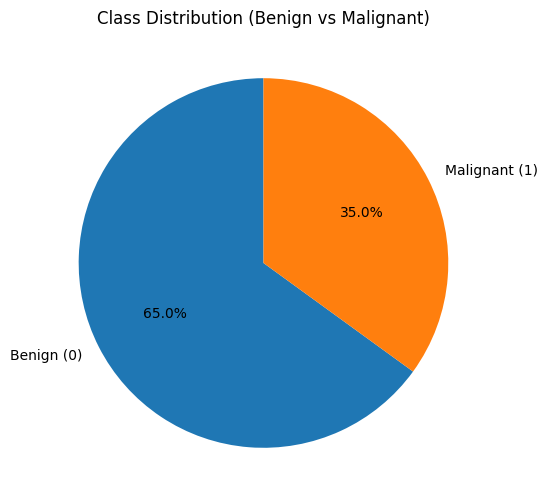

In [ ]:
# Count class values
class_counts = df['Class'].value_counts()

# Labels
labels = ['Benign (0)', 'Malignant (1)']

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(class_counts,labels=labels,autopct='%1.1f%%',startangle=90)
plt.title("Class Distribution (Benign vs Malignant)")
plt.show()


### A point to note is that there is class imbalance in this dataset

### The features here are categorical and therefore in the same scale only. Hence we do not need to use any Scaling technique over here

### Splitting the data

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
X

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1
...,...,...,...,...,...,...,...,...,...
694,3,1,1,1,3,2.0,1,1,1
695,2,1,1,1,2,1.0,1,1,1
696,5,10,10,3,7,3.0,8,10,2
697,4,8,6,4,3,4.0,10,6,1


In [ ]:
y

,Class
0,0
1,0
2,0
3,0
4,0
...,...
694,0
695,0
696,1
697,1


### Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## FEATURE SELECTION + SCALING

<Axes: >

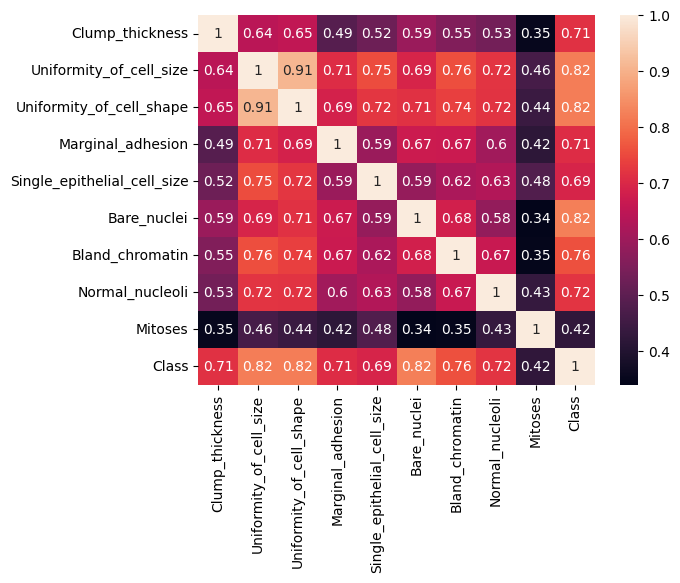

In [ ]:
sns.heatmap(df.corr(), annot=True)

#### Uniformity_of_cell_size vs Uniformity_of_cell_shape = 0.91 (very high correlation). So we can remove one of these

In [ ]:
X_train = X_train.drop('Uniformity_of_cell_shape', axis=1)
X_test  = X_test.drop('Uniformity_of_cell_shape', axis=1)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test_scaled)
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9635036496350365


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97        79
           1       0.98      0.93      0.96        58

    accuracy                           0.96       137
   macro avg       0.97      0.96      0.96       137
weighted avg       0.96      0.96      0.96       137



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[78  1]
 [ 4 54]]


In [ ]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [ ]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.9975993016150153


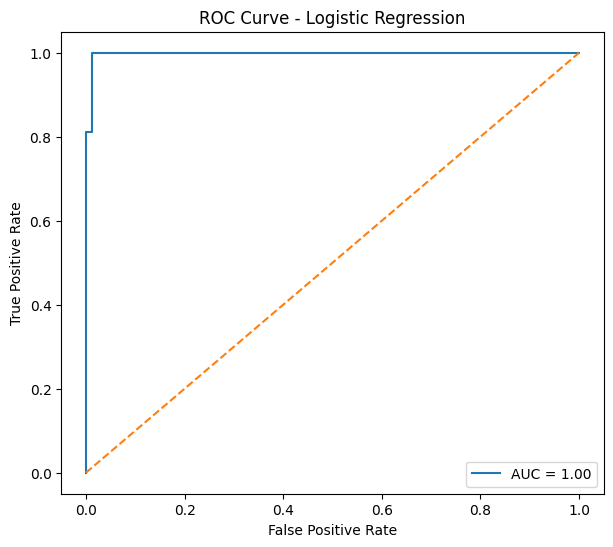

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")

plt.plot([0, 1], [0, 1], linestyle="--")  # random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [ ]:
auc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.9975993016150153


## SVM

In [ ]:
from sklearn.svm import SVC

In [ ]:
model = SVC()

In [ ]:
model.fit(X_train_scaled,y_train)

SVC()

In [ ]:
predictions = model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
print(confusion_matrix(y_test,predictions))

[[77  2]
 [ 3 55]]


In [ ]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97        79
           1       0.96      0.95      0.96        58

    accuracy                           0.96       137
   macro avg       0.96      0.96      0.96       137
weighted avg       0.96      0.96      0.96       137



In [ ]:
print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.9635036496350365


Using Grid Search CV

In [ ]:
param_grid = {'C': [0.1,1, 10, 100, 1000], 'gamma': [1,0.1,0.01,0.001,0.0001], 'kernel': ['rbf']}

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
grid = GridSearchCV(SVC(),param_grid,refit=True,verbose=1)

First, it runs the same loop with cross-validation, to find the best parameter combination. Once it has the best combination, it runs fit again on all data passed to fit (without cross-validation), to built a single new model using the best parameter setting.

In [ ]:
grid.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=1)

In [ ]:
grid.best_params_

{'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}

In [ ]:
grid.best_estimator_

SVC(C=0.1, gamma=0.1)

In [ ]:
grid_predictions = grid.predict(X_test_scaled)

In [ ]:
print(confusion_matrix(y_test,grid_predictions))

[[77  2]
 [ 3 55]]


In [ ]:
print(classification_report(y_test,grid_predictions))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97        79
           1       0.96      0.95      0.96        58

    accuracy                           0.96       137
   macro avg       0.96      0.96      0.96       137
weighted avg       0.96      0.96      0.96       137



Another set of parameters

In [ ]:
param_grid = {'C': [50,75,100,125,150], 'gamma': [1e-2,1e-3,1e-4,1e-5,1e-6], 'kernel': ['rbf']}
grid = GridSearchCV(SVC(tol=1e-5),param_grid,refit=True,verbose=1)
grid.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


GridSearchCV(estimator=SVC(tol=1e-05),
             param_grid={'C': [50, 75, 100, 125, 150],
                         'gamma': [0.01, 0.001, 0.0001, 1e-05, 1e-06],
                         'kernel': ['rbf']},
             verbose=1)

In [ ]:
grid.best_params_

{'C': 75, 'gamma': 0.0001, 'kernel': 'rbf'}

In [ ]:
grid.best_estimator_

SVC(C=75, gamma=0.0001, tol=1e-05)

In [ ]:
grid_predictions = grid.predict(X_test_scaled)

In [ ]:
print(confusion_matrix(y_test,grid_predictions))

[[78  1]
 [ 3 55]]


In [ ]:
print(classification_report(y_test,grid_predictions))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        79
           1       0.98      0.95      0.96        58

    accuracy                           0.97       137
   macro avg       0.97      0.97      0.97       137
weighted avg       0.97      0.97      0.97       137



## DECISION TREE

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
model = DecisionTreeClassifier()

model.fit(X_train_scaled, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9635036496350365


In [ ]:
print(confusion_matrix(y_test, y_pred))

[[77  2]
 [ 3 55]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97        79
           1       0.96      0.95      0.96        58

    accuracy                           0.96       137
   macro avg       0.96      0.96      0.96       137
weighted avg       0.96      0.96      0.96       137



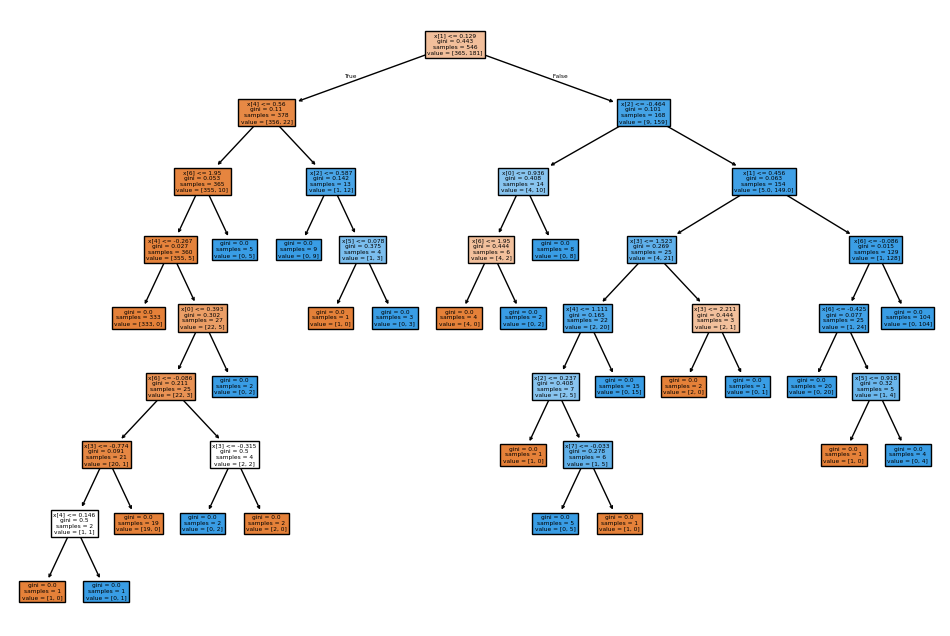

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(model, filled=True)
plt.show()

## RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
rfc = RandomForestClassifier(n_estimators=100, random_state=42) # n_estimators is the number of trees

rfc.fit(X_train, y_train) # Random Forest does not require scaling, so we use X_train (not scaled)

RandomForestClassifier(random_state=42)

In [ ]:
rfc_pred = rfc.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, rfc_pred))

Accuracy: 0.9708029197080292


In [ ]:
print(classification_report(y_test, rfc_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        79
           1       0.98      0.95      0.96        58

    accuracy                           0.97       137
   macro avg       0.97      0.97      0.97       137
weighted avg       0.97      0.97      0.97       137



In [ ]:
cm = confusion_matrix(y_test, rfc_pred)
print(cm)

[[78  1]
 [ 3 55]]


### Running a loop with increasing number of trees in the random forest and checking accuracy of confusion matrix
**Criterion 'gini' or 'entropy'**

In [ ]:
accuracy_gini = []
accuracy_entropy = []
ntree = []

for i in range(1, 21):
    n = i * 10

    # Gini
    rfc_gini = RandomForestClassifier(n_estimators=n, criterion='gini', random_state=42)
    rfc_gini.fit(X_train, y_train)
    pred_gini = rfc_gini.predict(X_test)
    acc_gini = accuracy_score(y_test, pred_gini)

    # Entropy
    rfc_entropy = RandomForestClassifier(n_estimators=n, criterion='entropy', random_state=42)
    rfc_entropy.fit(X_train, y_train)
    pred_entropy = rfc_entropy.predict(X_test)
    acc_entropy = accuracy_score(y_test, pred_entropy)

    ntree.append(n)
    accuracy_gini.append(acc_gini)
    accuracy_entropy.append(acc_entropy)

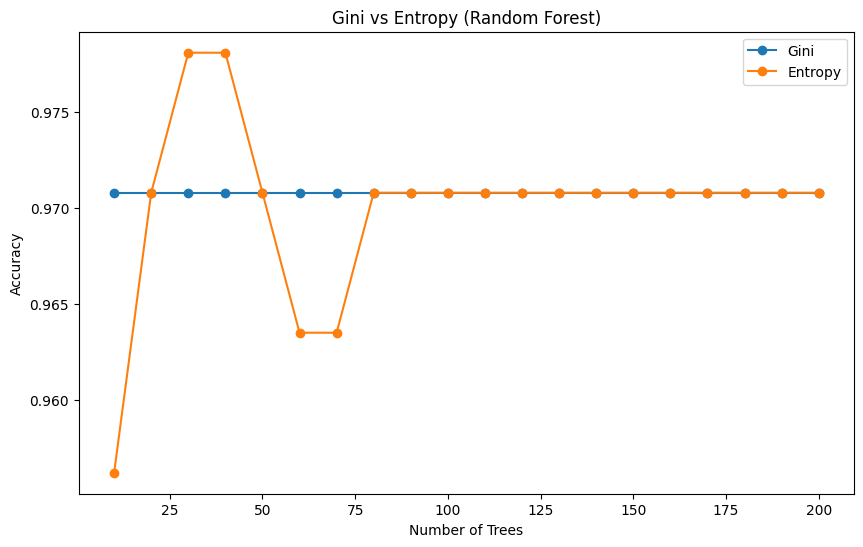

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(ntree, accuracy_gini, label='Gini', marker='o')
plt.plot(ntree, accuracy_entropy, label='Entropy', marker='o')

plt.title("Gini vs Entropy (Random Forest)")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

## Insights from Gini vs Entropy Plot
1. Both methods perform almost the same overall

After ~80 trees, both Gini and Entropy converge to ~0.971 accuracy.

This means:

Both splitting criteria are equally effective for this dataset
Choice of criterion does not significantly affect performance

2. Entropy shows more fluctuation at low trees

From your graph:

Entropy starts low (0.956)
Then peaks (0.978 around 30–40 trees)
Then drops again

Interpretation:

Entropy is less stable when the number of trees is small.

3. Gini is more stable
Gini accuracy remains almost constant (~0.971) across all tree values

Interpretation:

Gini provides consistent performance, even with fewer trees.

4. After a certain number of trees, performance stabilizes
Around 80–100 trees, both curves become flat

Interpretation:

Increasing trees beyond this point does not improve accuracy

5. No overfitting trend observed
Accuracy does not drop with more trees

Interpretation:

Random Forest is robust and does not easily overfit with more trees.

**Criterion max_entropy**

In [ ]:
accuracy_depth = []
ntree = []

for i in range(1, 21):
    n = i * 10

    rfc = RandomForestClassifier(n_estimators=n, max_depth=5, random_state=42)
    rfc.fit(X_train, y_train)

    pred = rfc.predict(X_test)
    acc = accuracy_score(y_test, pred)

    ntree.append(n)
    accuracy_depth.append(acc)

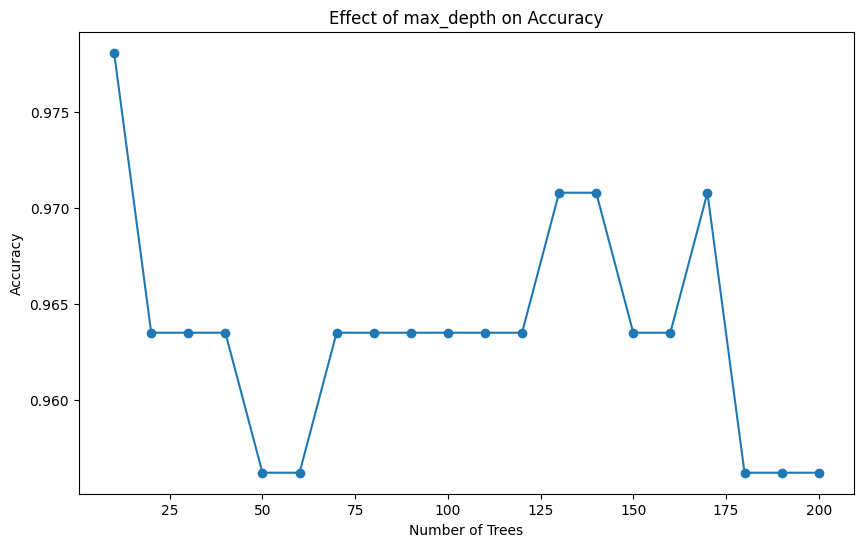

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(ntree, accuracy_depth, marker='o')

plt.title("Effect of max_depth on Accuracy")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")

plt.show()

1. Best performance occurs at shallow depth
Highest accuracy (~0.978) is achieved at low number of trees (around 10)

Interpretation:

A limited tree depth (max_depth = 5) helps prevent overfitting and gives better generalization.

2. Accuracy drops when number of trees increases initially
Accuracy decreases around 20–60 trees (~0.956–0.963)

👉 Interpretation:

Increasing trees does not always improve performance when tree depth is restricted. The model may become slightly less optimal due to limited complexity.

3. Performance stabilizes for moderate number of trees
From 70 to 150 trees, accuracy stabilizes (~0.963–0.971)

Interpretation:

After a certain point, adding more trees provides consistent but not improved performance.

4. Fluctuations indicate limited model flexibility
Accuracy fluctuates instead of steadily increasing

👉 Interpretation:

Since max_depth = 5, trees cannot grow fully, so the model has limited capacity to learn complex patterns.

5. Slight drop at very high number of trees
Around 180–200 trees, accuracy drops again (~0.956)

Interpretation:

Too many shallow trees may introduce redundancy without adding useful information.

**Criterion min_samples_split**

In [ ]:
accuracy_split = []
ntree = []

for i in range(1, 21):
    n = i * 10

    rfc = RandomForestClassifier(n_estimators=n, min_samples_split=10, random_state=42)
    rfc.fit(X_train, y_train)

    pred = rfc.predict(X_test)
    acc = accuracy_score(y_test, pred)

    ntree.append(n)
    accuracy_split.append(acc)

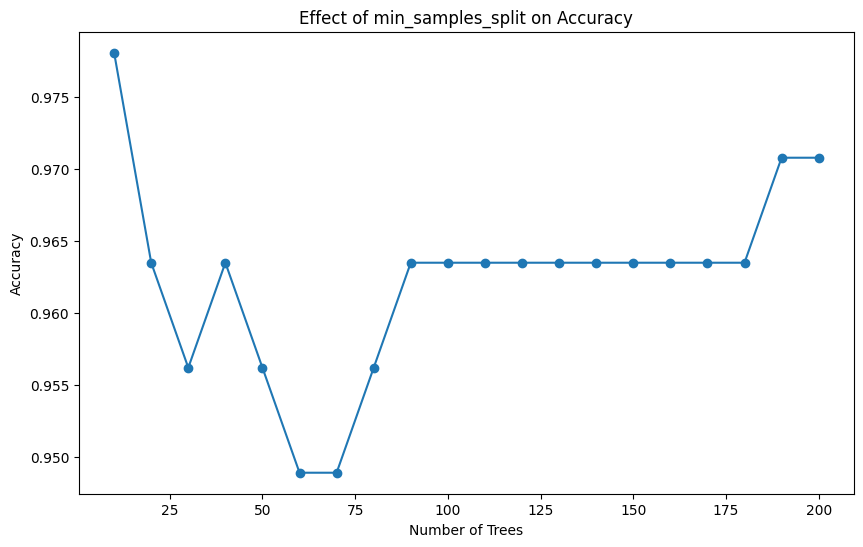

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(ntree, accuracy_split, marker='o')

plt.title("Effect of min_samples_split on Accuracy")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")

plt.show()

1. Best accuracy at small split size
Highest accuracy (~0.978) occurs at low number of trees (around 10)

Interpretation:

Smaller min_samples_split allows the tree to split more freely, capturing more detailed patterns in the data.

2. Accuracy drops as trees increase initially
Accuracy decreases around 30–70 trees (~0.949–0.956)

Interpretation:

With min_samples_split = 10, the model becomes more restrictive, limiting splits and reducing flexibility.

3. Performance stabilizes after moderate number of trees
From 90 to 180 trees, accuracy stabilizes (~0.963)

Interpretation:

The model reaches a point where adding more trees does not significantly improve performance.

4. Slight improvement at very high number of trees
Around 190–200 trees, accuracy increases again (~0.971)

Interpretation:

A larger number of trees helps compensate for the restrictive splitting condition, improving performance slightly.

5. Restrictive splitting reduces model complexity
Lower accuracy compared to fully flexible trees

Interpretation:

Higher min_samples_split prevents overfitting but may lead to underfitting if too restrictive.